In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [18]:
class SelfPruningNet(nn.Module):
    def __init__(self):
        super(SelfPruningNet, self).__init__()
        self.fc1 = PrunableLinear(3 * 32 * 32, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_sparsity_loss(self):
        sparsity_loss = 0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                sparsity_loss += torch.sigmoid(module.gate_scores).sum()
        return sparsity_loss

In [19]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

def train(lam, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SelfPruningNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            classification_loss = criterion(outputs, labels)
            sparsity_loss = model.get_sparsity_loss()
            loss = classification_loss + lam * sparsity_loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"λ={lam} | Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(trainloader):.4f}")

    return model

In [20]:
def evaluate(model, lam, threshold=1e-2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    total_weights = 0
    pruned_weights = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total_weights += gates.numel()
            pruned_weights += (gates < threshold).sum().item()

    sparsity = 100 * pruned_weights / total_weights
    print(f"λ={lam} | Accuracy: {accuracy:.2f}% | Sparsity: {sparsity:.2f}%")
    return accuracy, sparsity




In [21]:
import matplotlib.pyplot as plt

def plot_gates(model, lam):
    all_gates = []
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    plt.figure(figsize=(8, 4))
    plt.hist(all_gates, bins=100, color='steelblue', edgecolor='none')
    plt.title(f'Gate Value Distribution (λ={lam})')
    plt.xlabel('Gate Value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(f'gates_lambda_{lam}.png')
    plt.show()


Training with λ=0
λ=0 | Epoch 1/10 | Loss: 1.6803
λ=0 | Epoch 2/10 | Loss: 1.4356
λ=0 | Epoch 3/10 | Loss: 1.3066
λ=0 | Epoch 4/10 | Loss: 1.2031
λ=0 | Epoch 5/10 | Loss: 1.1148
λ=0 | Epoch 6/10 | Loss: 1.0335
λ=0 | Epoch 7/10 | Loss: 0.9520
λ=0 | Epoch 8/10 | Loss: 0.8727
λ=0 | Epoch 9/10 | Loss: 0.7988
λ=0 | Epoch 10/10 | Loss: 0.7256
λ=0 | Accuracy: 55.50% | Sparsity: 0.00%

Training with λ=1e-05
λ=1e-05 | Epoch 1/10 | Loss: 8.7592
λ=1e-05 | Epoch 2/10 | Loss: 6.3249
λ=1e-05 | Epoch 3/10 | Loss: 4.9191
λ=1e-05 | Epoch 4/10 | Loss: 4.0738
λ=1e-05 | Epoch 5/10 | Loss: 3.5259
λ=1e-05 | Epoch 6/10 | Loss: 3.1419
λ=1e-05 | Epoch 7/10 | Loss: 2.8574
λ=1e-05 | Epoch 8/10 | Loss: 2.6305
λ=1e-05 | Epoch 9/10 | Loss: 2.4505
λ=1e-05 | Epoch 10/10 | Loss: 2.2933
λ=1e-05 | Accuracy: 56.12% | Sparsity: 1.92%

Training with λ=0.0001
λ=0.0001 | Epoch 1/10 | Loss: 71.0577
λ=0.0001 | Epoch 2/10 | Loss: 44.6916
λ=0.0001 | Epoch 3/10 | Loss: 28.3501
λ=0.0001 | Epoch 4/10 | Loss: 18.9294
λ=0.0001 | Epo

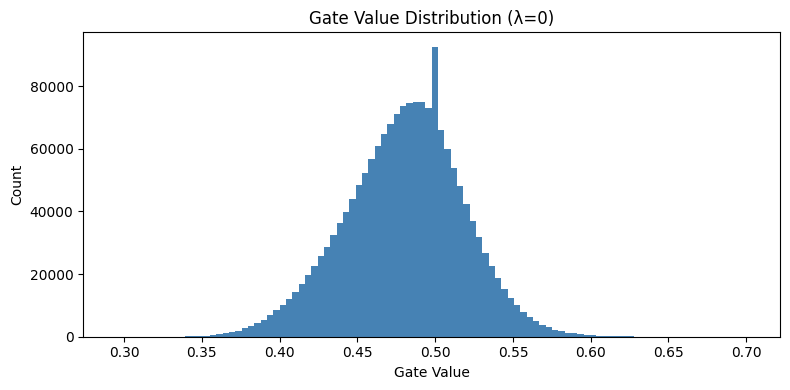

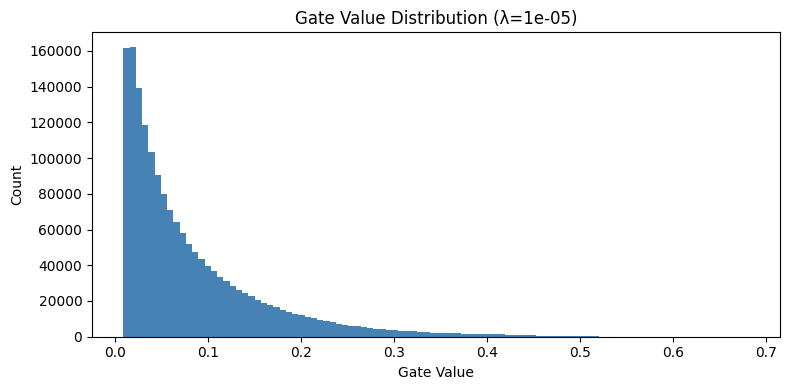

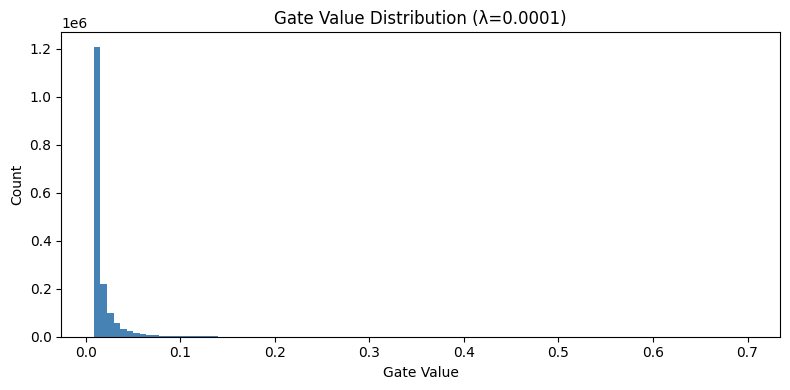

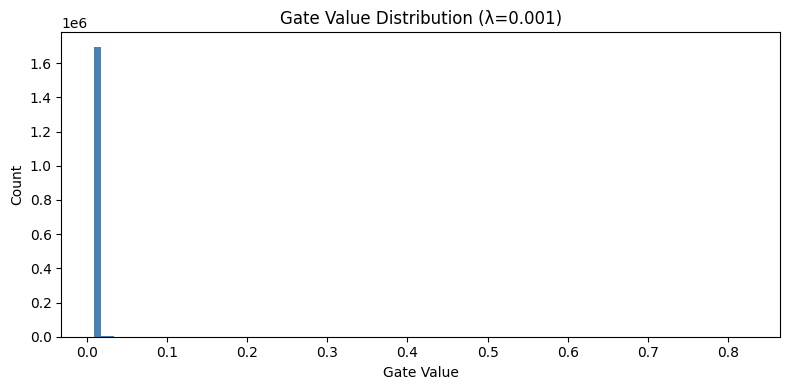

In [23]:
lambdas = [0,1e-5, 1e-4, 1e-3]
results = []
models = []

for lam in lambdas:
    print(f"\nTraining with λ={lam}")
    model = train(lam)
    acc, sparsity = evaluate(model, lam)
    results.append((lam, acc, sparsity))
    models.append((lam, model))

print("\n Final Results ")
for lam, acc, sparsity in results:
    print(f"λ={lam} | Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")

for lam, model in models:
    plot_gates(model, lam)